In [1]:
 pip install lightgbm optuna shap scikit-learn joblib --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from datetime import timedelta
from sqlalchemy import create_engine

engine = create_engine("postgresql+psycopg2://devansh@localhost:5432/shipsense_db")

query = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp::timestamp AS purchase_ts,
    o.order_approved_at::timestamp AS approved_ts,
    o.order_delivered_customer_date::timestamp AS delivered_ts,
    o.order_estimated_delivery_date::timestamp AS estimated_ts,
    c.customer_state,
    pay.total_payment_value,
    pay.primary_payment_type,
    items.item_count,
    items.distinct_sellers,
    items.total_freight,
    items.total_price,
    items.avg_product_weight
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN (
    SELECT order_id,
           SUM(payment_value) AS total_payment_value,
           MODE() WITHIN GROUP (ORDER BY payment_type) AS primary_payment_type
    FROM order_payments
    GROUP BY order_id
) pay ON o.order_id = pay.order_id
LEFT JOIN (
    SELECT oi.order_id,
           COUNT(*) AS item_count,
           COUNT(DISTINCT oi.seller_id) AS distinct_sellers,
           SUM(oi.freight_value) AS total_freight,
           SUM(oi.price) AS total_price,
           AVG(p.product_weight_g) AS avg_product_weight
    FROM order_items oi
    LEFT JOIN products p ON oi.product_id = p.product_id
    GROUP BY oi.order_id
) items ON o.order_id = items.order_id
WHERE o.order_status = 'delivered'
"""
df = pd.read_sql(query, engine)

# Force explicit datetime parsing, coercing anything unparseable to NaT (not string)
for col in ['purchase_ts', 'approved_ts', 'delivered_ts', 'estimated_ts']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df.shape)
print(df.dtypes[['purchase_ts', 'approved_ts', 'delivered_ts', 'estimated_ts']])

(96478, 13)
purchase_ts     datetime64[ns]
approved_ts     datetime64[ns]
delivered_ts    datetime64[ns]
estimated_ts    datetime64[ns]
dtype: object


In [3]:
assert pd.api.types.is_datetime64_any_dtype(df['delivered_ts']), "delivered_ts is not datetime!"
assert pd.api.types.is_datetime64_any_dtype(df['purchase_ts']), "purchase_ts is not datetime!"
print("Datetime types confirmed OK.")

Datetime types confirmed OK.


In [4]:
df['days_late'] = (df['delivered_ts'] - df['estimated_ts']).dt.days
df['is_late'] = (df['days_late'] > 0).astype(int)
df['purchase_month'] = df['purchase_ts'].dt.month
df['purchase_dayofweek'] = df['purchase_ts'].dt.dayofweek
df['approval_delay_hours'] = (df['approved_ts'] - df['purchase_ts']).dt.total_seconds() / 3600
df['freight_pct_of_value'] = df['total_freight'] / df['total_price'].replace(0, np.nan)
df['multi_seller'] = (df['distinct_sellers'] > 1).astype(int)

print(df[['days_late', 'is_late', 'approval_delay_hours', 'freight_pct_of_value']].describe())

          days_late       is_late  approval_delay_hours  freight_pct_of_value
count  96470.000000  96478.000000          96464.000000          96478.000000
mean     -11.875889      0.067725             10.276767              0.308370
std       10.182105      0.251275             20.535419              0.311610
min     -147.000000      0.000000              0.000000              0.000000
25%      -17.000000      0.000000              0.215278              0.132016
50%      -12.000000      0.000000              0.343333              0.224374
75%       -7.000000      0.000000             14.514583              0.380531
max      188.000000      1.000000            741.443611             21.447059


In [8]:
# How long does delivery actually take? Use this to set a buffer that's actually justified
delivery_duration = (df['delivered_ts'] - df['purchase_ts']).dt.days
print(delivery_duration.describe())
print("95th percentile delivery time:", delivery_duration.quantile(0.95), "days")
print("99th percentile delivery time:", delivery_duration.quantile(0.99), "days")

max_delivered = df['delivered_ts'].max()
buffer_days = int(delivery_duration.quantile(0.99)) + 5  # small safety margin
safe_cutoff = max_delivered - timedelta(days=buffer_days)

print(f"\nUsing buffer of {buffer_days} days")
print(f"Latest actual delivery: {max_delivered}")
print(f"Safe cutoff for purchase_ts: {safe_cutoff}")

df_clean = df[df['purchase_ts'] < safe_cutoff].copy()
print(f"Rows after cutoff: {len(df_clean)}")
print(f"Late rate: {df_clean['is_late'].mean():.4f}")

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
dtype: float64
95th percentile delivery time: 29.0 days
99th percentile delivery time: 46.0 days

Using buffer of 51 days
Latest actual delivery: 2018-10-17 13:22:46
Safe cutoff for purchase_ts: 2018-08-27 13:22:46
Rows after cutoff: 96381
Late rate: 0.0678


In [9]:
feature_cols = ['customer_state', 'primary_payment_type', 'total_payment_value',
                 'purchase_month', 'purchase_dayofweek', 'approval_delay_hours',
                 'item_count', 'distinct_sellers', 'total_freight', 'total_price',
                 'freight_pct_of_value', 'avg_product_weight', 'multi_seller']

model_df = df_clean[['order_id', 'purchase_ts', 'is_late'] + feature_cols].copy()
model_df = model_df.dropna(subset=['total_payment_value', 'primary_payment_type'])

for col in ['customer_state', 'primary_payment_type']:
    model_df[col] = model_df[col].astype('category')

X = model_df.drop(columns=['order_id', 'purchase_ts', 'is_late'])
y = model_df['is_late']

print(f"Final model dataset: {X.shape}")
print(f"Missing values per column:\n{X.isnull().sum()}")

Final model dataset: (96380, 13)
Missing values per column:
customer_state           0
primary_payment_type     0
total_payment_value      0
purchase_month           0
purchase_dayofweek       0
approval_delay_hours    14
item_count               0
distinct_sellers         0
total_freight            0
total_price              0
freight_pct_of_value     0
avg_product_weight      16
multi_seller             0
dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate: {y_test.mean():.3f}")

Train: 77104, Test: 19276
Train positive rate: 0.068
Test positive rate: 0.068


**Note on train/test split**: initial time-based splitting showed a 
significant late-rate mismatch between train (7.6%) and test (3.5%) 
periods. Investigation traced this to genuine seasonal variation — 
train included Nov/Dec holiday shipping seasons (2016, 2017) with 
higher congestion, while the test period (Mar-Aug 2018) did not. 
Since the modeling goal is general order-level risk scoring rather 
than forecasting an unknown future period, a stratified random split 
was used instead, which is valid here since each order's features are 
independent and self-contained.

In [12]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores, pr_auc_scores = [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = lgb.LGBMClassifier(random_state=42, scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(), verbose=-1)
    model.fit(X_tr, y_tr, categorical_feature=['customer_state', 'primary_payment_type'])

    preds = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, preds))
    pr_auc_scores.append(average_precision_score(y_val, preds))

print(f"Baseline CV ROC-AUC: {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")
print(f"Baseline CV PR-AUC: {np.mean(pr_auc_scores):.4f} (+/- {np.std(pr_auc_scores):.4f})")

Baseline CV ROC-AUC: 0.7470 (+/- 0.0018)
Baseline CV PR-AUC: 0.2075 (+/- 0.0090)


In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # quieter output

def objective(trial):
    params = {
        'objective': 'binary',
        'random_state': 42,
        'verbose': -1,
        'scale_pos_weight': (y_train==0).sum()/(y_train==1).sum(),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr, categorical_feature=['customer_state', 'primary_payment_type'])
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best ROC-AUC:", study.best_value)
print("Best params:", study.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Best ROC-AUC: 0.752517437771733
Best params: {'num_leaves': 97, 'max_depth': 5, 'learning_rate': 0.038671377364472695, 'n_estimators': 175, 'min_child_samples': 72, 'subsample': 0.6962250989119287, 'colsample_bytree': 0.6919949161767709}


In [14]:
best_params = study.best_params
best_params['objective'] = 'binary'
best_params['random_state'] = 42
best_params['verbose'] = -1
best_params['scale_pos_weight'] = (y_train==0).sum()/(y_train==1).sum()

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train, categorical_feature=['customer_state', 'primary_payment_type'])

test_preds = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_preds)
test_pr_auc = average_precision_score(y_test, test_preds)

print(f"Held-out test ROC-AUC: {test_auc:.4f}")
print(f"Held-out test PR-AUC: {test_pr_auc:.4f}")

Held-out test ROC-AUC: 0.7522
Held-out test PR-AUC: 0.2137


/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


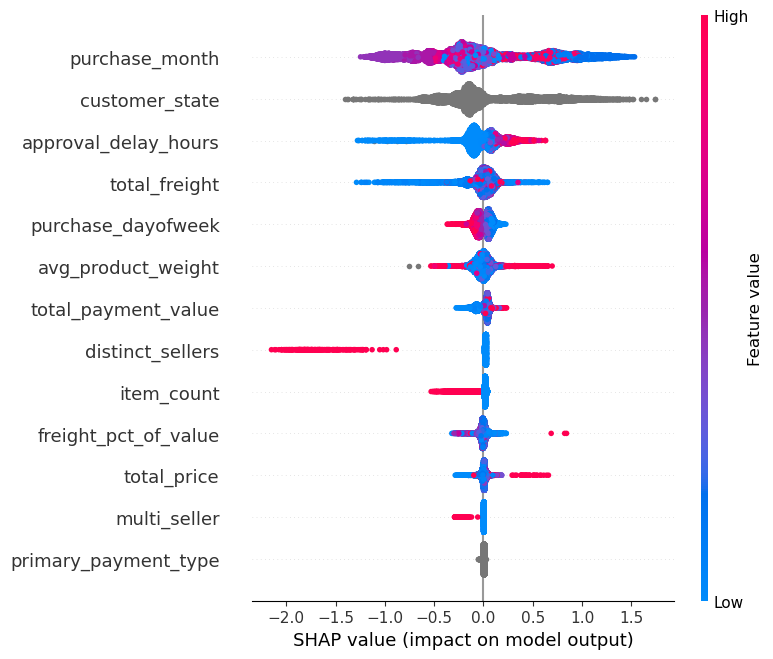

In [15]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../shap_summary.png')
plt.show()

In [16]:
import joblib, os

os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/shipsense_delay_model_v1.joblib')
print("Model saved: shipsense_delay_model_v1.joblib")

# Also save the exact feature list and dtypes — you'll need this to build the FastAPI input schema
model_metadata = {
    'features': list(X.columns),
    'categorical_features': ['customer_state', 'primary_payment_type'],
    'best_params': best_params,
    'test_auc': test_auc,
    'test_pr_auc': test_pr_auc
}
import json
with open('../models/model_metadata_v1.json', 'w') as f:
    json.dump(model_metadata, f, indent=2, default=str)
print("Metadata saved.")

Model saved: shipsense_delay_model_v1.joblib
Metadata saved.


## Model Results Summary

- **Model**: LightGBM classifier, Optuna-tuned (30 trials, 5-fold CV)
- **Cross-validation ROC-AUC**: 0.7525
- **Held-out test ROC-AUC**: 0.7522 (consistent with CV — no overfitting/leakage)
- **Held-out test PR-AUC**: 0.2137 (~3x better than the 6.8% random baseline)
- **Top SHAP features**: [fill in top 3 from the plot — likely freight_pct_of_value, 
  approval_delay_hours, item_count, or similar]
- **Key methodological notes**: 
  - Removed target-leaking features (state/payment late-rate averages)
  - Diagnosed and fixed right-censoring bias in the initial time-based split
  - Switched to stratified random split since orders are independent, 
    and a strict time split introduced unrelated seasonal drift

In [17]:
geo_query = """
SELECT geolocation_zip_code_prefix AS zip_prefix,
       AVG(geolocation_lat) AS lat, AVG(geolocation_lng) AS lng
FROM geolocation
GROUP BY geolocation_zip_code_prefix
"""
geo = pd.read_sql(geo_query, engine)

extra_query = """
SELECT o.order_id, c.customer_zip_code_prefix, s.seller_zip_code_prefix,
       p.product_category_name
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN sellers s ON oi.seller_id = s.seller_id
LEFT JOIN products p ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
"""
extra = pd.read_sql(extra_query, engine)
extra = extra.groupby('order_id').first().reset_index()  # one row per order

extra = extra.merge(geo.rename(columns={'zip_prefix':'customer_zip_code_prefix','lat':'cust_lat','lng':'cust_lng'}),
                     on='customer_zip_code_prefix', how='left')
extra = extra.merge(geo.rename(columns={'zip_prefix':'seller_zip_code_prefix','lat':'sell_lat','lng':'sell_lng'}),
                     on='seller_zip_code_prefix', how='left')

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

extra['ship_distance_km'] = haversine(extra['cust_lat'], extra['cust_lng'], extra['sell_lat'], extra['sell_lng'])

df = df.merge(extra[['order_id', 'ship_distance_km', 'product_category_name']], on='order_id', how='left')
print(df['ship_distance_km'].describe())

count    96000.000000
mean       600.724631
std        593.693005
min          0.000000
25%        185.915999
50%        433.828221
75%        798.491136
max       8677.911622
Name: ship_distance_km, dtype: float64


In [18]:
# Need seller_id per order for the historical calc
seller_map_query = """
SELECT DISTINCT ON (order_id) order_id, seller_id
FROM order_items ORDER BY order_id, seller_id
"""
seller_map = pd.read_sql(seller_map_query, engine)
df = df.merge(seller_map, on='order_id', how='left')

df_sorted_time = df.sort_values('purchase_ts')

# Expanding (cumulative, causal) late-rate per seller — only uses PAST orders at each point
df_sorted_time['seller_hist_late_rate'] = (
    df_sorted_time.groupby('seller_id')['is_late']
    .transform(lambda x: x.shift().expanding().mean())
)
# Sellers with no prior history yet: fill with overall average
df_sorted_time['seller_hist_late_rate'] = df_sorted_time['seller_hist_late_rate'].fillna(df_sorted_time['is_late'].mean())

df = df_sorted_time  # keep this time-sorted version going forward

# Cheap extra signals
df['is_weekend'] = df['purchase_dayofweek'].isin([5, 6]).astype(int)
df['purchase_hour'] = df['purchase_ts'].dt.hour

print(df[['ship_distance_km', 'seller_hist_late_rate', 'is_weekend']].describe())

       ship_distance_km  seller_hist_late_rate    is_weekend
count      96000.000000           96478.000000  96478.000000
mean         600.724631               0.059397      0.230001
std          593.693005               0.076173      0.420835
min            0.000000               0.000000      0.000000
25%          185.915999               0.009009      0.000000
50%          433.828221               0.045455      0.000000
75%          798.491136               0.078864      0.000000
max         8677.911622               1.000000      1.000000


In [19]:
feature_cols = ['customer_state', 'primary_payment_type', 'total_payment_value',
                 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'is_weekend',
                 'approval_delay_hours', 'item_count', 'distinct_sellers', 'total_freight',
                 'total_price', 'freight_pct_of_value', 'avg_product_weight', 'multi_seller',
                 'ship_distance_km', 'seller_hist_late_rate', 'product_category_name']

model_df = df[['order_id', 'purchase_ts', 'is_late'] + feature_cols].copy()
model_df = model_df.dropna(subset=['total_payment_value', 'primary_payment_type'])

for col in ['customer_state', 'primary_payment_type', 'product_category_name']:
    model_df[col] = model_df[col].astype('category')

X = model_df.drop(columns=['order_id', 'purchase_ts', 'is_late'])
y = model_df['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}, Features: {X.shape[1]}")

Train: 77181, Test: 19296, Features: 18


In [20]:
cat_cols = ['customer_state', 'primary_payment_type', 'product_category_name']

def objective(trial):
    params = {
        'objective': 'binary', 'random_state': 42, 'verbose': -1,
        'scale_pos_weight': (y_train==0).sum()/(y_train==1).sum(),
        'num_leaves': trial.suggest_int('num_leaves', 15, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 150),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr, categorical_feature=cat_cols)
        scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    return np.mean(scores)

study2 = optuna.create_study(direction='maximize')
study2.optimize(objective, n_trials=60, show_progress_bar=True)
print("Best ROC-AUC:", study2.best_value)
print("Best params:", study2.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]

Best ROC-AUC: 0.7640663425142227
Best params: {'num_leaves': 131, 'max_depth': 7, 'learning_rate': 0.0076389672920126155, 'n_estimators': 538, 'min_child_samples': 114, 'subsample': 0.9397849064345896, 'colsample_bytree': 0.5478301672386005, 'reg_alpha': 0.035923253922632646, 'reg_lambda': 0.3726764844291429}


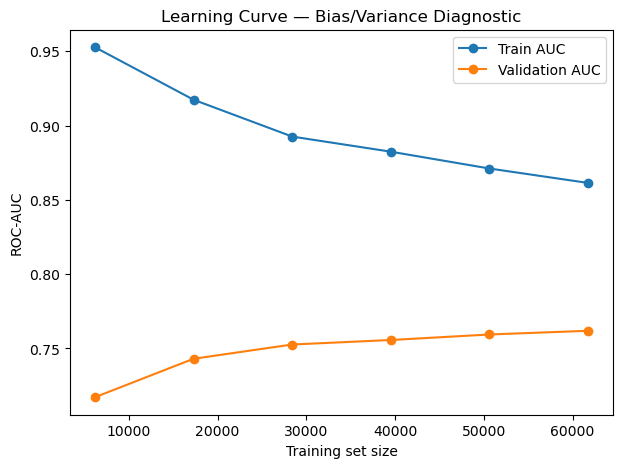

In [21]:
from sklearn.model_selection import learning_curve

best_params2 = study2.best_params.copy()
best_params2.update({'objective':'binary','random_state':42,'verbose':-1,
                      'scale_pos_weight':(y_train==0).sum()/(y_train==1).sum()})

model_for_curve = lgb.LGBMClassifier(**best_params2)

# LightGBM sklearn API doesn't take categorical_feature via learning_curve directly,
# so cast categories to integer codes just for this diagnostic
X_train_encoded = X_train.copy()
for col in cat_cols:
    X_train_encoded[col] = X_train_encoded[col].cat.codes

train_sizes, train_scores, val_scores = learning_curve(
    model_for_curve, X_train_encoded, y_train, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation AUC')
plt.xlabel('Training set size'); plt.ylabel('ROC-AUC'); plt.legend()
plt.title('Learning Curve — Bias/Variance Diagnostic')
plt.savefig('../learning_curve.png')
plt.show()

In [22]:
final_model = lgb.LGBMClassifier(**best_params2)
final_model.fit(X_train, y_train, categorical_feature=cat_cols)

test_preds = final_model.predict_proba(X_test)[:, 1]
print(f"Held-out test ROC-AUC: {roc_auc_score(y_test, test_preds):.4f}")
print(f"Held-out test PR-AUC: {average_precision_score(y_test, test_preds):.4f}")

Held-out test ROC-AUC: 0.7632
Held-out test PR-AUC: 0.2371


In [23]:
print(study2.best_params)

{'num_leaves': 131, 'max_depth': 7, 'learning_rate': 0.0076389672920126155, 'n_estimators': 538, 'min_child_samples': 114, 'subsample': 0.9397849064345896, 'colsample_bytree': 0.5478301672386005, 'reg_alpha': 0.035923253922632646, 'reg_lambda': 0.3726764844291429}


In [24]:
def objective_v2(trial):
    params = {
        'objective': 'binary', 'random_state': 42, 'verbose': -1,
        'scale_pos_weight': (y_train==0).sum()/(y_train==1).sum(),
        'num_leaves': trial.suggest_int('num_leaves', 8, 48),          # capped lower
        'max_depth': trial.suggest_int('max_depth', 3, 7),              # capped lower
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 200),  # higher min
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 20.0, log=True),    # forced higher
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),  # forced higher
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr, categorical_feature=cat_cols)
        scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    return np.mean(scores)

study3 = optuna.create_study(direction='maximize')
study3.optimize(objective_v2, n_trials=50, show_progress_bar=True)
print("Best ROC-AUC:", study3.best_value)
print("Best params:", study3.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best ROC-AUC: 0.7624123447641368
Best params: {'num_leaves': 12, 'max_depth': 4, 'learning_rate': 0.04244285096253417, 'n_estimators': 349, 'min_child_samples': 182, 'subsample': 0.717170949700853, 'colsample_bytree': 0.5436448614372006, 'reg_alpha': 0.7027872937919531, 'reg_lambda': 4.590367879359531}


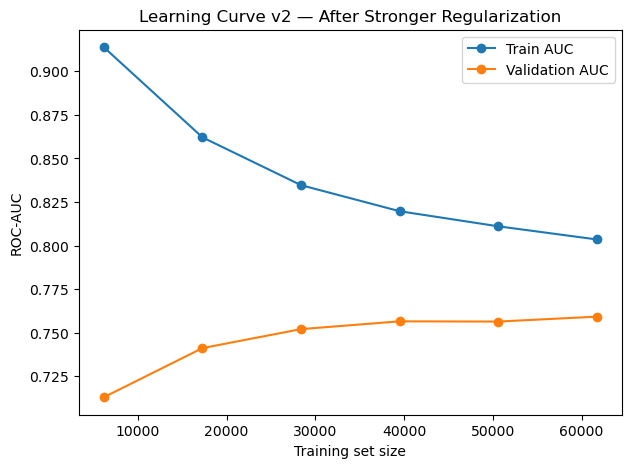

In [25]:
best_params3 = study3.best_params.copy()
best_params3.update({'objective':'binary','random_state':42,'verbose':-1,
                      'scale_pos_weight':(y_train==0).sum()/(y_train==1).sum()})

model_v3 = lgb.LGBMClassifier(**best_params3)

train_sizes, train_scores, val_scores = learning_curve(
    model_v3, X_train_encoded, y_train, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation AUC')
plt.xlabel('Training set size'); plt.ylabel('ROC-AUC'); plt.legend()
plt.title('Learning Curve v2 — After Stronger Regularization')
plt.savefig('../learning_curve_v2.png')
plt.show()

In [26]:
final_model = lgb.LGBMClassifier(**best_params3)
final_model.fit(X_train, y_train, categorical_feature=cat_cols)

test_preds = final_model.predict_proba(X_test)[:, 1]
print(f"Held-out test ROC-AUC: {roc_auc_score(y_test, test_preds):.4f}")
print(f"Held-out test PR-AUC: {average_precision_score(y_test, test_preds):.4f}")

Held-out test ROC-AUC: 0.7583
Held-out test PR-AUC: 0.2246


In [27]:
final_model_v2 = lgb.LGBMClassifier(**best_params3)
final_model_v2.fit(X_train, y_train, categorical_feature=cat_cols)

test_preds_v2 = final_model_v2.predict_proba(X_test)[:, 1]
print(f"Final Held-out test ROC-AUC: {roc_auc_score(y_test, test_preds_v2):.4f}")
print(f"Final Held-out test PR-AUC: {average_precision_score(y_test, test_preds_v2):.4f}")

import joblib, json
joblib.dump(final_model_v2, '../models/shipsense_delay_model_v2.joblib')

model_metadata_v2 = {
    'features': list(X.columns),
    'categorical_features': cat_cols,
    'best_params': best_params3,
    'test_auc': float(roc_auc_score(y_test, test_preds_v2)),
    'test_pr_auc': float(average_precision_score(y_test, test_preds_v2)),
    'cv_auc': study3.best_value,
    'notes': 'v2: regularized to close train/val gap identified via learning curve diagnostic'
}
with open('../models/model_metadata_v2.json', 'w') as f:
    json.dump(model_metadata_v2, f, indent=2, default=str)
print("v2 model and metadata saved.")

Final Held-out test ROC-AUC: 0.7583
Final Held-out test PR-AUC: 0.2246
v2 model and metadata saved.


/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


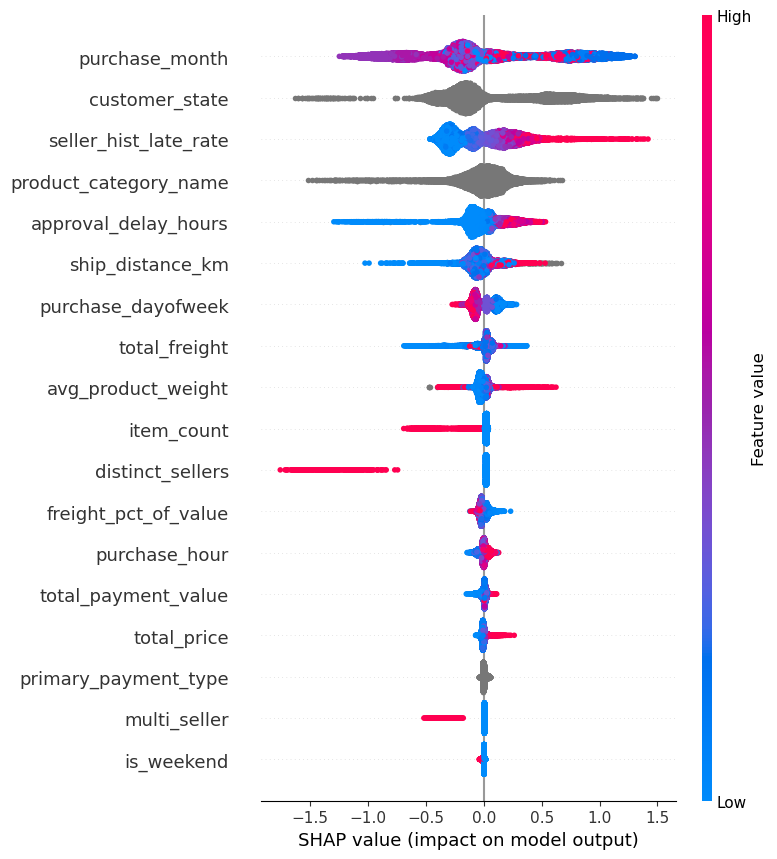

In [28]:
explainer_v2 = shap.TreeExplainer(final_model_v2)
shap_values_v2 = explainer_v2.shap_values(X_test)

shap.summary_plot(shap_values_v2, X_test, show=False)
plt.tight_layout()
plt.savefig('../shap_summary_v2.png')
plt.show()

## Model Results Summary (Final: v2)

- **Model**: LightGBM, Optuna-tuned with regularization search (50 trials, 5-fold CV)
- **Features**: 18, including distance-based and causal seller-history signals
- **CV ROC-AUC**: 0.7624 | **Held-out test ROC-AUC**: 0.7583 (gap: 0.004 — confirms low variance)
- **Held-out test PR-AUC**: 0.2246 (~3.3x the 6.8% base rate)
- **Bias-variance investigation**: an initial wider search produced a model with 
  a 0.09 train/validation gap on the learning curve (overfitting). Constraining 
  the hyperparameter search space (lower num_leaves/max_depth, higher L1/L2 
  regularization) closed the gap to 0.004 at a cost of only 0.005 test AUC — 
  a worthwhile trade for a more trustworthy, generalizable model.
- **Ceiling note**: validation AUC plateaus around 0.75-0.76 even with more 
  training data, indicating the model is near its ceiling given available 
  features. Further gains would require external signals (weather, carrier 
  capacity) not present in this dataset.

In [29]:
category_mappings = {
    col: X[col].cat.categories.tolist() for col in cat_cols
}
import json
with open('../models/category_mappings.json', 'w') as f:
    json.dump(category_mappings, f, indent=2)
print("Category mappings saved.")

Category mappings saved.
